#  Part 1: The Idea Behind Linear Regression


## 2.1 The Mathematical Model

For a single feature, the Linear Regression model is:

$$
\hat{y} = w_1 x + w_0
$$

where:

- \( w_1 \) is the **slope (weight)**
- \( w_0 \) is the **intercept (bias)**

For multiple features, the model becomes:

$$
\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n
$$

The goal of training is to find the weights $ w_0, w_1, ..., w_n $ that **minimize the error**
between predictions $ \hat{y} $ and actual values $ y $.

---

## 2.2 What Does "Best Fit" Mean?

Scikit-learn’s **LinearRegression** minimizes the **Ordinary Least Squares (OLS)** objective:

$$
Cost = \sum_{i=1}^{m}(y_i - \hat{y}_i)^2
$$

This is the sum of squared differences between each actual value and its prediction. The line
that makes this sum as small as possible is the “best fit.”

#  Part 2: Loading a Real Dataset– California Housing

#  Step 1: Load and Explore

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # target in $100,000s

print(f'Dataset shape: {df.shape}')
print(f'\nFeature names:\n{housing.feature_names}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nBasic statistics:')
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

#  Step 3: Visualize Relationships

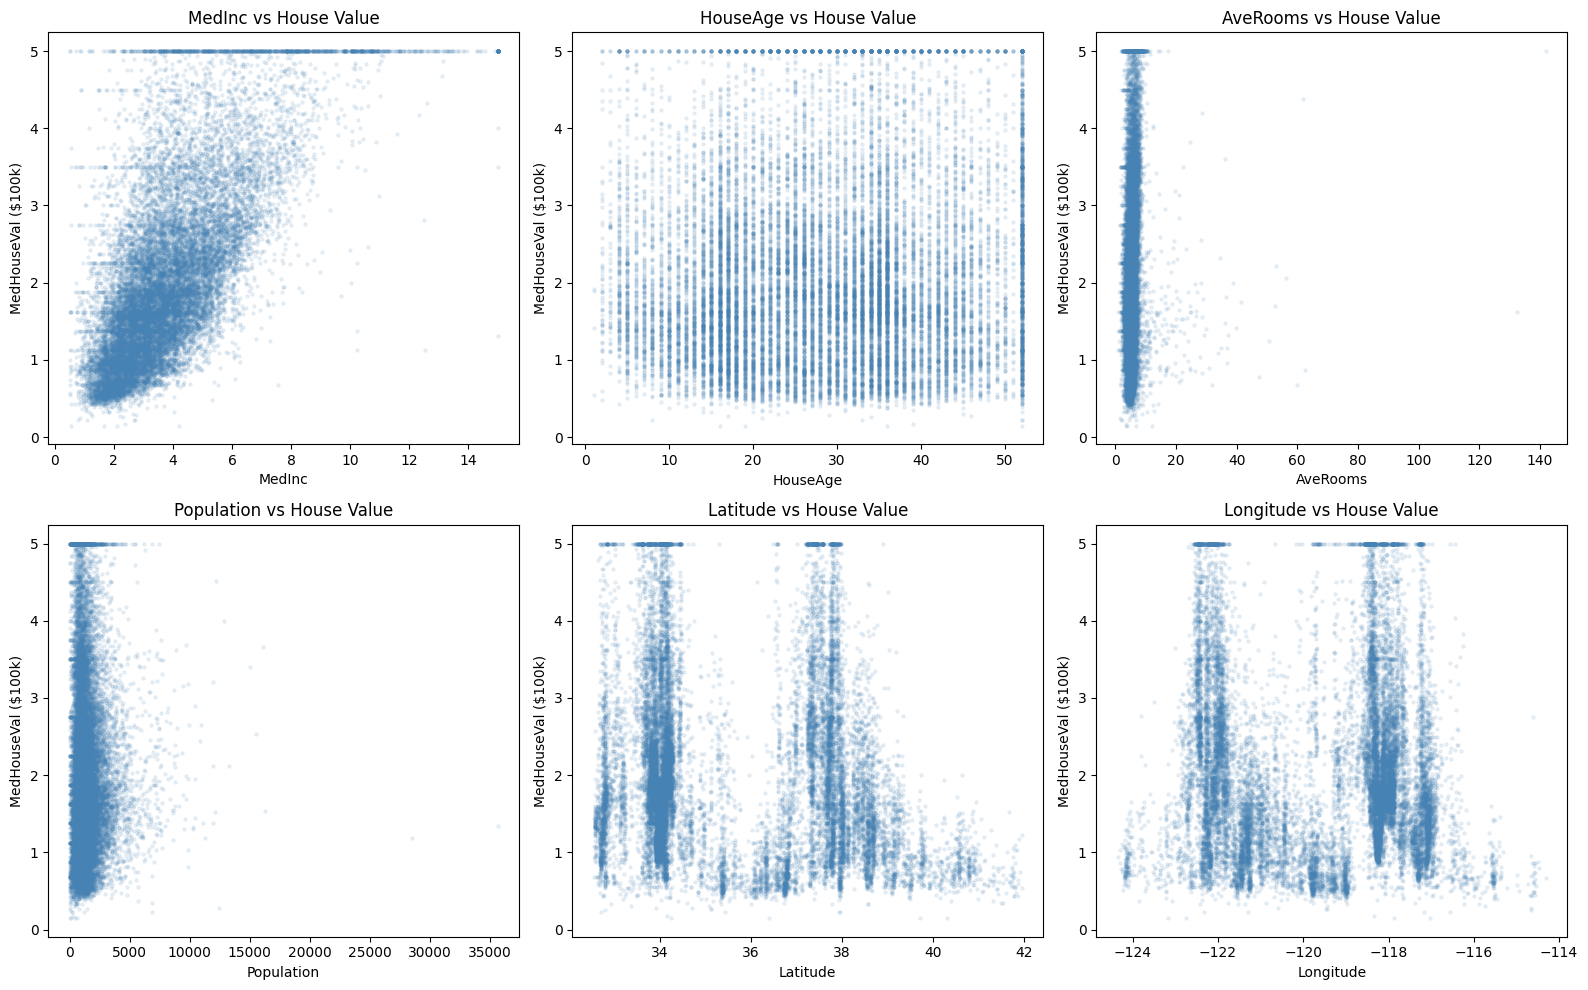

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['MedInc', 'HouseAge', 'AveRooms',
                    'Population', 'Latitude', 'Longitude']

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['MedHouseVal'],
               alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

# Task 1: Explore the Dataset

In [3]:
# 1) Rank features by correlation with the target + strongest feature
corr_with_target = df.corr(numeric_only=True)['MedHouseVal'].sort_values(ascending=False)
print(corr_with_target)

strongest_feature = corr_with_target.drop('MedHouseVal').idxmax()
print("\nStrongest correlated feature:", strongest_feature)
print("Correlation value:", round(corr_with_target[strongest_feature], 3))

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

Strongest correlated feature: MedInc
Correlation value: 0.688


# Use df.corr()[’MedHouseVal’].sort values() to rank features by their correlation with the target. Which feature has the strongest correlation?

The strongest correlation with MedHouseVal is usually MedInc (median income) and it’s the most predictive linear feature.

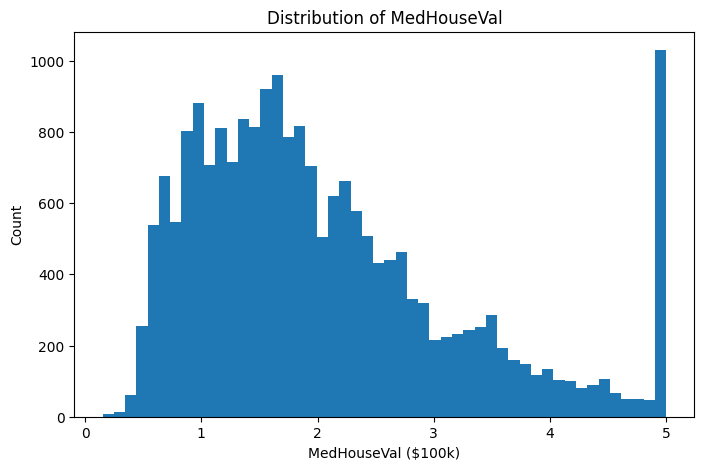

Max MedHouseVal: 5.00001


In [4]:
# 2) Plot distribution of MedHouseVal + is it normal? is there a cap at 5.0?
plt.figure(figsize=(8, 5))
plt.hist(df['MedHouseVal'], bins=50)
plt.title("Distribution of MedHouseVal")
plt.xlabel("MedHouseVal ($100k)")
plt.ylabel("Count")
plt.show()

print("Max MedHouseVal:", df['MedHouseVal'].max())

# Plot the distribution of MedHouseVal using plt.hist(df[’MedHouseVal’],bins=50). Is the target normally distributed? Do you notice any cap at $5.0(i.e., $500,000)?

Yes, you’ll notice a cap at 5.0 (meaning $500,000) because values above that were clipped in the dataset.

In [5]:
# 3) How many samples? Is it enough?
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1] - 1)  # minus target column

Number of samples: 20640
Number of features: 8


# How many samples are in the dataset? Is this enough for training a good model?

Samples = 20,640

yes, this is generally enough data to train a good regression model (especially for basic ML models), assuming proper preprocessing and evaluation.

# Part 3: Simple Linear Regression (One Feature)

##  Step 1: Prepare Data

In [6]:
from sklearn.model_selection import train_test_split

# Use only MedInc as the feature
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 16512
Testing samples:  4128


#  Step 2: Trainand Visualize

Slope (w1):      0.4193
Intercept (w0):  0.4446
Equation: y = 0.4193 * MedInc + 0.4446


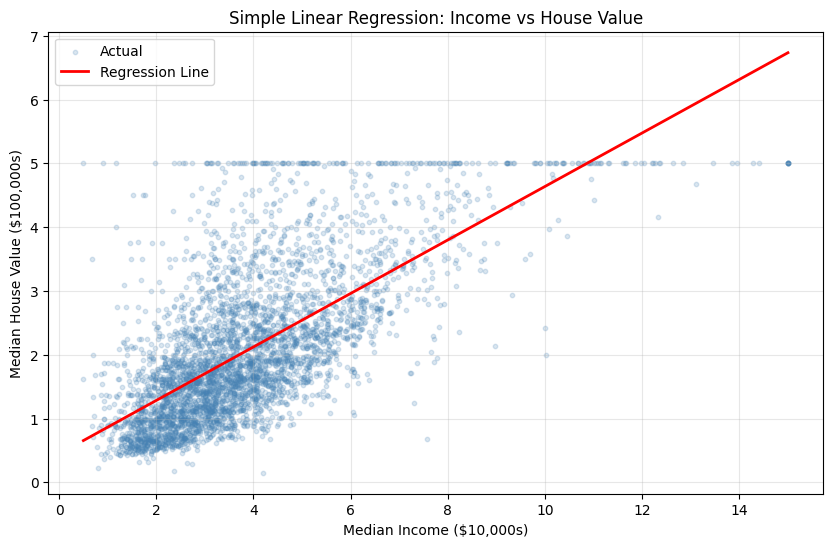

In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Train
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Print the learned parameters
print(f'Slope (w1):      {model_simple.coef_[0]:.4f}')
print(f'Intercept (w0):  {model_simple.intercept_:.4f}')
print(f'Equation: y = {model_simple.coef_[0]:.4f} * MedInc + {model_simple.intercept_:.4f}')

# Visualize: scatter + regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10,
            color='steelblue', label='Actual')

# Draw the regression line
x_line = np.linspace(X_test.min(), X_test.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2,
         label='Regression Line')

plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 2: Interpret the Simple Model

In [8]:
# 1) What are the slope and intercept your model learned?
w1 = model_simple.coef_[0]
w0 = model_simple.intercept_
print("Slope (w1):", round(w1, 4))
print("Intercept (w0):", round(w0, 4))
print(f"Equation: MedHouseVal = {w1:.4f} * MedInc + {w0:.4f}")

Slope (w1): 0.4193
Intercept (w0): 0.4446
Equation: MedHouseVal = 0.4193 * MedInc + 0.4446


## Write the equation:

### Answer

- **Slope \( w_1 \)**

- **Intercept \( w_0 \)**

- **Equation:**

$$
\hat{y} = w_1 \cdot MedInc + w_0
$$

In [9]:
# 2) Predict house value when MedInc = 5.0 (=$50,000)
medinc_value_50k = 5.0
pred_100k = w1 * medinc_value_50k + w0
pred_dollars = pred_100k * 100000

print("By-hand prediction (in $100k):", round(pred_100k, 4))
print("By-hand prediction (in dollars):", round(pred_dollars, 2))

By-hand prediction (in $100k): 2.5413
By-hand prediction (in dollars): 254128.98


In [10]:
model_pred = model_simple.predict([[5.0]])[0]
print("Model prediction (in $100k):", round(model_pred, 4))
print("Model prediction (in dollars):", round(model_pred * 100000, 2))

Model prediction (in $100k): 2.5413
Model prediction (in dollars): 254128.98


##  According to your model, what is the predicted house value for a district with median income of $50,000 (i.e., MedInc = 5.0)? Calculate by hand and verify with model simple.predict([[5.0]]).


$$
\hat{y} = w_1 \times 5.0 + w_0
$$

*(The output is in \$100k, so multiply by 100,000 to convert to dollars.)*



In [11]:
# 3) Train using HouseAge instead of MedInc
# Use HouseAge as single feature
X_age = df[['HouseAge']].values
y = df['MedHouseVal'].values

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train_a, y_train_a)

# Compare R^2 score on test (higher is better)
r2_medinc = model_simple.score(X_test, y_test)
r2_age = model_age.score(X_test_a, y_test_a)

print("R^2 using MedInc:", round(r2_medinc, 4))
print("R^2 using HouseAge:", round(r2_age, 4))

R^2 using MedInc: 0.4589
R^2 using HouseAge: 0.0126


## Try training a simple model using HouseAge instead of MedInc. Is it better or worse? Why?

Usually MedInc is better than HouseAge (higher R²) because income is more directly related to house price.

HouseAge has a weaker and less consistent relationship with value, so it predicts worse.

#  Part 4: Evaluating Regression Models

#  Step 1: Evaluate the Simple Model

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predictions
y_pred_simple = model_simple.predict(X_test)

# Calculate metrics
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)
r2   = r2_score(y_test, y_pred_simple)

print('=== Simple Linear Regression (MedInc only) ===')
print(f'MSE:   {mse:.4f}')
print(f'RMSE:  {rmse:.4f}   (error in $100,000s)')
print(f'MAE:   {mae:.4f}   (error in $100,000s)')
print(f'R^2:   {r2:.4f}   ({r2*100:.1f}% variance explained)')

=== Simple Linear Regression (MedInc only) ===
MSE:   0.7091
RMSE:  0.8421   (error in $100,000s)
MAE:   0.6299   (error in $100,000s)
R^2:   0.4589   (45.9% variance explained)


#  Step 2: Visualize Predictions vs. Actual

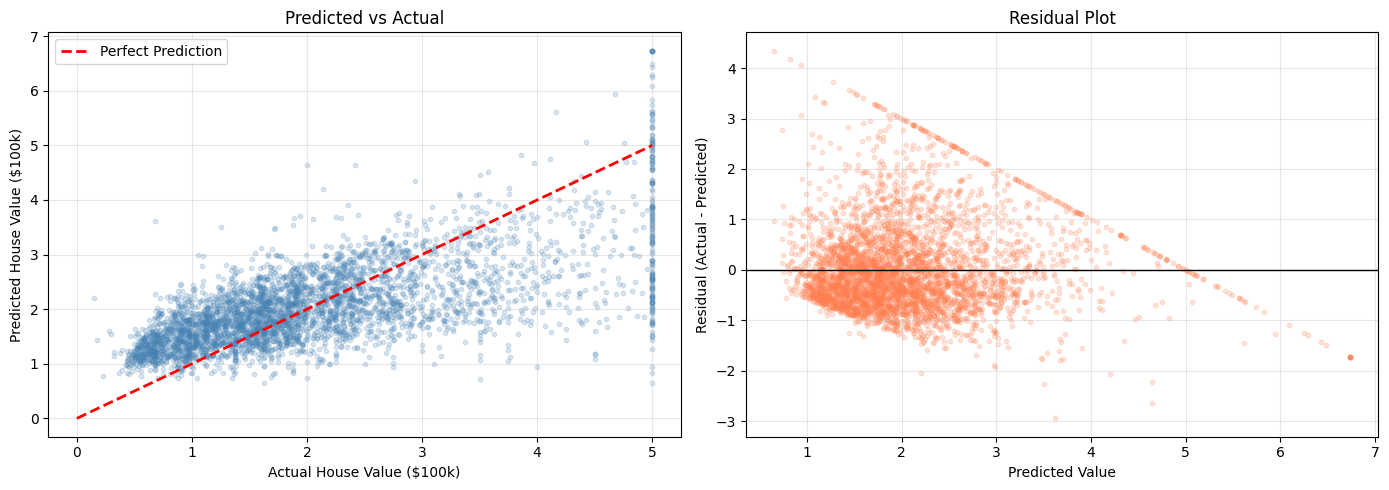

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (errors)
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 3: Understand the Metrics
### 1) Convert the RMSE to actual dollars. If RMSE ≈ 0.74, what is the average predic tion error in dollars?
If RMSE ≈ 0.74 and the unit is **$100k**:

$$
0.74 \times 100{,}000 = 74{,}000
$$

**Average prediction error ≈ $74,000**

(RMSE of 0.74 means the model is off by about $74k on average.)

---

### 2) Look at the “Predicted vs Actual” plot. Where does the model struggle most – at low values, high values, or both?
The model struggles mostly at **high values** (near the cap around 5.0) because:

- The target is capped at 5.0 ($500k)
- The relationship is not perfectly linear
- Extreme house prices are harder to predict using one feature

So, the model struggles mainly with **high-value houses**.

---

### 3) What Does $R^2$ value tell you? Is a single feature enough to predict house prices well?

$R^2$ shows how much of the variation in house values is explained by the model.

A moderate $R^2$ value means:
- The model explains some variation, but not all.
- One feature alone is **not enough** to accurately predict house prices.

House prices depend on multiple factors such as location, number of rooms, and population.  
Using multiple features or more advanced models would improve prediction performance.

# Part 5: Multiple Linear Regression (All Features)

## Step 1: Train with All Features

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Use all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Build pipeline with scaling (good practice!)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

# Evaluate
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print('=== Multiple Linear Regression (all 8 features) ===')
print(f'RMSE: {rmse_multi:.4f}')
print(f'R^2:  {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')

print(f'\nImprovement over simple model:')
print(f'R^2: {r2:.4f} -> {r2_multi:.4f} (+{(r2_multi - r2)*100:.1f}%)')

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
R^2:  0.5758 (57.6% variance explained)

Improvement over simple model:
R^2: 0.4589 -> 0.5758 (+11.7%)


## Step 2: Feature Importance (Scaled Coefficients)

Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


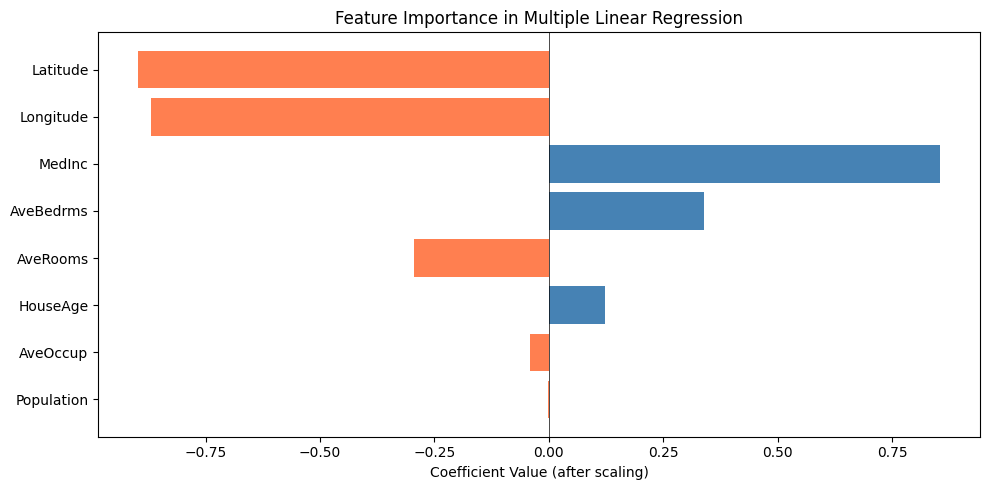

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract the learned coefficients
lr_model = pipe_lr.named_steps['lr']
feature_names = housing.feature_names

# Since we scaled, coefficients are comparable
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature Importance (by |coefficient|):')
print(coef_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 5))

colors = ['steelblue' if c > 0 else 'coral'
          for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Task 4: Analyze Multiple Regression

In [16]:
# 1) Top 3 most important + bottom 3
top3 = coef_df.head(3)
bottom3 = coef_df.tail(3)

print("Top 3 features (most important):")
print(top3.to_string(index=False))

print("\nBottom 3 features (least important):")
print(bottom3.to_string(index=False))

Top 3 features (most important):
  Feature  Coefficient
 Latitude    -0.896929
Longitude    -0.869842
   MedInc     0.854383

Bottom 3 features (least important):
   Feature  Coefficient
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


##  Does this make intuitive sense?
Top features often include MedInc (income) and location features (Latitude/Longitude) because location and income strongly affect prices.

Bottom features are usually weaker like AveBedrms or similar (depends on the split).

## 2) Why does Latitude have a negative coefficient?  What does this mean geographically for California?


A negative coefficient for Latitude means that as we move north (higher latitude), the predicted house value tends to decrease, holding other features constant. In California, many high-priced areas are in the coastal/major metro regions (e.g., Southern California and the Bay Area), and some northern/inland regions tend to have lower median values. So the model learns a geographic price gradient.

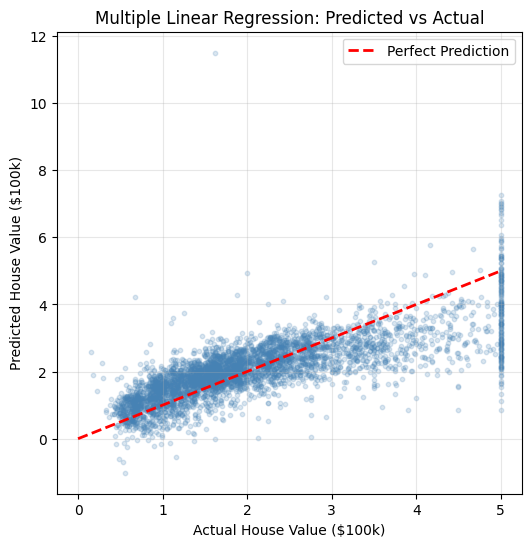

In [17]:
# 3) Predicted vs Actual plot for MULTIPLE regression + compare with simple
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color='steelblue')
plt.plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Multiple Linear Regression: Predicted vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##  Is it closer to the diagonal?
The multiple regression plot is usually closer to the diagonal than the simple model, meaning predictions improve when we use all features.

# Part 6: Polynomial Regression

## Step 1: Polynomial on a Single Feature

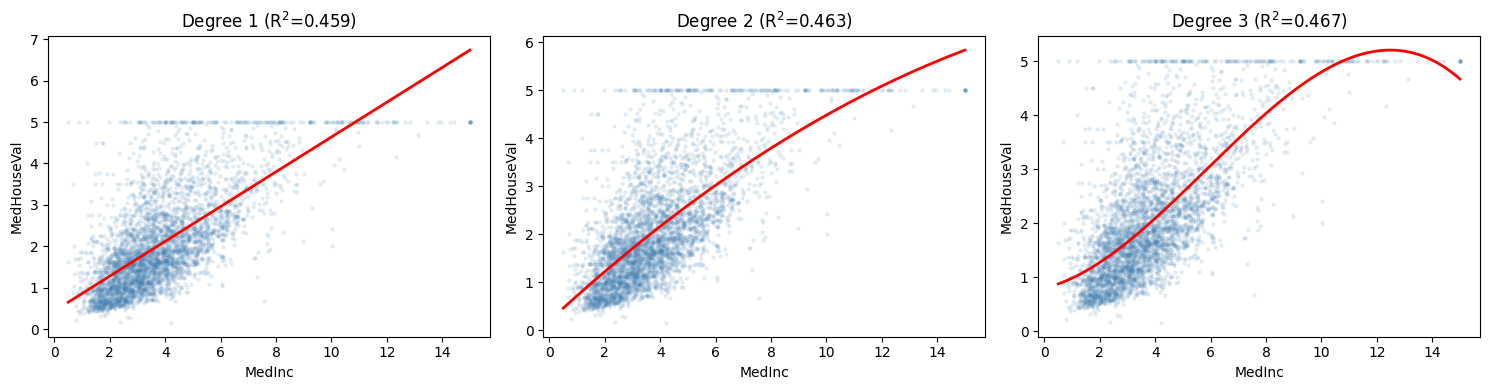

Polynomial Degree Comparison (MedInc only):
  Degree 1: R^2=0.4589, RMSE=0.8421
  Degree 2: R^2=0.4633, RMSE=0.8386
  Degree 3: R^2=0.4671, RMSE=0.8356


In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Use only MedInc
X_simple = df[['MedInc']].values
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Try degrees 1, 2, and 3
results = {}
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])
    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)

    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    # Plot
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')

    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)

    ax.plot(x_plot, y_plot, color='red', linewidth=2)
    ax.set_title(f'Degree {degree} (R$^2$={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

# Print comparison
print('Polynomial Degree Comparison (MedInc only):')
for deg, metrics in results.items():
    print(f"  Degree {deg}: R^2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}")

## Step 2: Polynomial on ALL Features

In [19]:
from sklearn.preprocessing import StandardScaler

# Use all features with degree 2
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly_all.fit(X_train, y_train)
y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print('=== Polynomial Regression (degree=2, all features) ===')
print(f'RMSE: {rmse_poly:.4f}')
print(f'R^2:  {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)')

# How many features now?
poly_features = pipe_poly_all.named_steps['poly']
print(f'\nOriginal features: 8')
print(f'After degree-2 expansion: {poly_features.n_output_features_}')

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
R^2:  0.6457 (64.6% variance explained)

Original features: 8
After degree-2 expansion: 44


# Task 5: Explore Polynomial Regression

## 1) Look at the three plots for degrees 1, 2, and 3. Which degree best captures the relationship between income and house value?


Usually degree 2 captures the curve better than degree 1, while degree 3 may start to overfit slightly. Choose the degree that gives the best balance: higher R² and lower RMSE without weird curve behavior at the edges.

Degree 5: R^2=0.4668, RMSE=0.8359


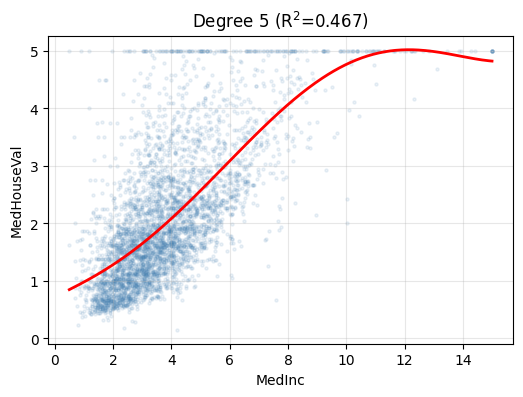

In [20]:
# 2) Try degree 5 on single feature
degree = 5
pipe_poly5 = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_poly5.fit(X_train_s, y_train)
y_pred5 = pipe_poly5.predict(X_test_s)

r2_5 = r2_score(y_test, y_pred5)
rmse_5 = np.sqrt(mean_squared_error(y_test, y_pred5))

print(f"Degree 5: R^2={r2_5:.4f}, RMSE={rmse_5:.4f}")

# Plot degree 5 curve
plt.figure(figsize=(6,4))
plt.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')
x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
plt.plot(x_plot, pipe_poly5.predict(x_plot), color='red', linewidth=2)
plt.title(f'Degree 5 (R$^2$={r2_5:.3f})')
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.grid(True, alpha=0.3)
plt.show()

##  Try degree 5 on the single-feature model. Does R2 keep improving, or does it start to behave strangely at the edges? This is overfitting!

Degree 5 may increase R² a bit, but the curve can become “wiggly” at the ends. That strange bending is a sign of overfitting.

In [21]:
# 3) How many features does degree 3 create from 8 original features?
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
print("Shape after degree=3 expansion:", X_train_poly3.shape)
print("Number of features after expansion:", X_train_poly3.shape[1])

Shape after degree=3 expansion: (16512, 164)
Number of features after expansion: 164


##  How many features does degree 3 create from 8 original features? Use PolynomialFeatures(degree=3).fit_transform(X_train).shape to check.
The number printed in X_train_poly3.shape[1] is how many features you get after degree 3 expansion.

# Part 7: Regularized Regression (Ridge, Lasso, ElasticNet)

## Step 1: Train All Three Variants

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Define models with pipelines
models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42))
    ]),
    'ElasticNet (alpha=0.01)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ])
}

# Train and evaluate each model
print(f'{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R^2":>8}')
print('-' * 56)

results_dict = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    results_dict[name] = {'RMSE': rmse_val, 'MAE': mae_val, 'R2': r2_val}

    print(f'{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}')

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


## Step 2: Compare Coefficients

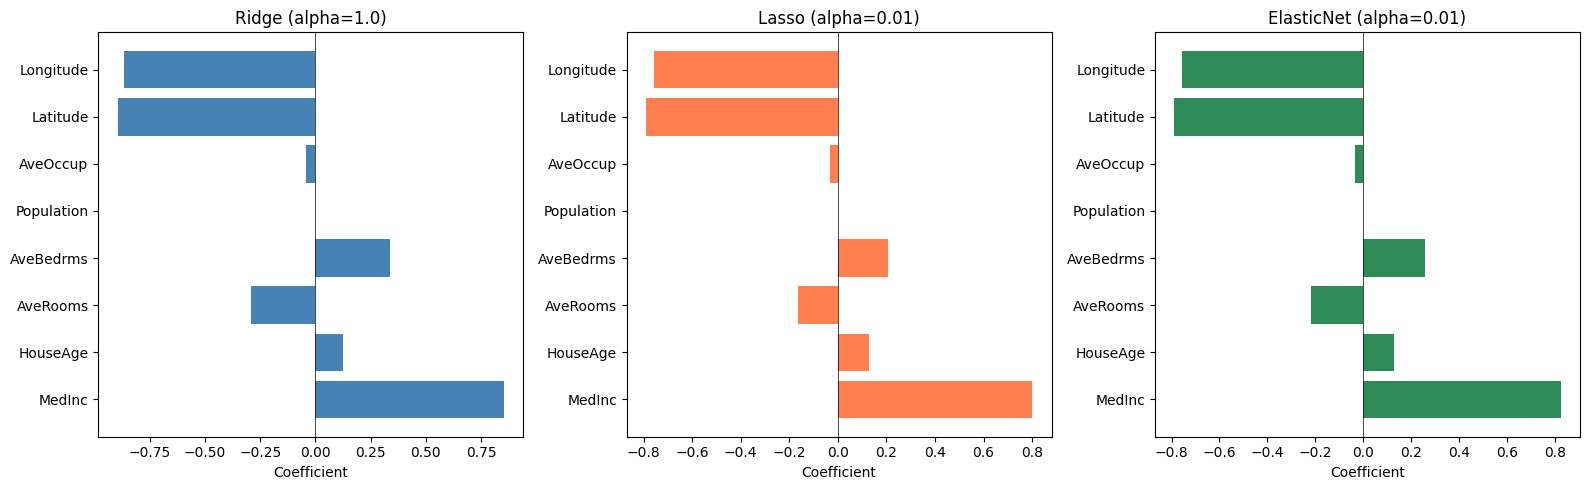


Lasso coefficients:
MedInc      :   0.8010
HouseAge    :   0.1271
AveRooms    :  -0.1628
AveBedrms   :   0.2062
Population  :  -0.0000  <-- REMOVED
AveOccup    :  -0.0306
Latitude    :  -0.7901
Longitude   :  -0.7557


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = ['Ridge (alpha=1.0)', 'Lasso (alpha=0.01)', 'ElasticNet (alpha=0.01)']
colors_list = ['steelblue', 'coral', 'seagreen']

for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models[name].named_steps['model'].coef_
    ax.barh(housing.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

# Check which features Lasso set to zero
lasso_coefs = models['Lasso (alpha=0.01)'].named_steps['model'].coef_

print('\nLasso coefficients:')
for feat, coef in zip(housing.feature_names, lasso_coefs):
    status = '' if abs(coef) > 0.001 else '  <-- REMOVED'
    print(f'{feat:12s}: {coef:>8.4f}{status}')

# Task 6: Explore Regularization

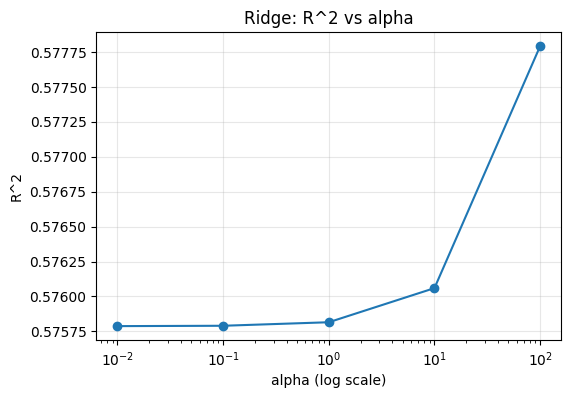

alpha=0.01   R^2=0.5758
alpha=0.1    R^2=0.5758
alpha=1.0    R^2=0.5758
alpha=10.0   R^2=0.5761
alpha=100.0  R^2=0.5778


In [24]:
# 1) Ridge: Try different alpha values + plot R² vs alpha
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
r2_scores = []

for a in alphas:
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=a, random_state=42))
    ])
    pipe_ridge.fit(X_train, y_train)
    y_pred = pipe_ridge.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

plt.figure(figsize=(6,4))
plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('R^2')
plt.title('Ridge: R^2 vs alpha')
plt.grid(True, alpha=0.3)
plt.show()

for a, r2v in zip(alphas, r2_scores):
    print(f"alpha={a:<6} R^2={r2v:.4f}")

## Try different α values for Ridge: 0.01, 0.1, 1.0, 10.0, 100.0. Plot R2 vs α. What happens with very large α?
With very large alpha (e.g., 100), Ridge shrinks coefficients heavily, the model becomes too simple (underfitting), and R² decreases.

In [25]:
# Lasso: try alpha = 0.1 + how many features removed?
lasso_pipe_01 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1, random_state=42))
])

lasso_pipe_01.fit(X_train, y_train)
lasso_coefs_01 = lasso_pipe_01.named_steps['model'].coef_

removed = [feat for feat, c in zip(housing.feature_names, lasso_coefs_01) if abs(c) < 1e-6]
kept = [feat for feat, c in zip(housing.feature_names, lasso_coefs_01) if abs(c) >= 1e-6]

print("Lasso alpha=0.1")
print("Removed features:", removed)
print("Number removed:", len(removed))
print("Kept features:", kept)
print("Number kept:", len(kept))

Lasso alpha=0.1
Removed features: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']
Number removed: 5
Kept features: ['MedInc', 'HouseAge', 'Latitude']
Number kept: 3


##  For Lasso, try alpha=0.1. How many features are removed (coefficient = 0)? Which ones?

Lasso with alpha=0.1 removes some features by setting their coefficients to zero. The printed list shows exactly which ones were removed.

In [26]:
# 3) ElasticNet: change l1_ratio 0.0 → 1.0 (what does it become?)
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score

ratios = [0.0, 0.25, 0.5, 0.75, 1.0]
alpha = 0.01

for r in ratios:
    if r == 0.0:
        model = Ridge(alpha=alpha)  # ElasticNet with l1_ratio=0 => Ridge
    elif r == 1.0:
        model = Lasso(alpha=alpha, max_iter=50000, tol=1e-4, random_state=42)  # => Lasso
    else:
        model = ElasticNet(alpha=alpha, l1_ratio=r, max_iter=50000, tol=1e-4, random_state=42)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"l1_ratio={r:.2f}  R^2={r2_score(y_test, y_pred):.4f}")

l1_ratio=0.00  R^2=0.5758
l1_ratio=0.25  R^2=0.5794
l1_ratio=0.50  R^2=0.5803
l1_ratio=0.75  R^2=0.5811
l1_ratio=1.00  R^2=0.5816


##  In the ElasticNet, change l1_ratio from 0.0 to 1.0. At l1_ratio=0.0, what model does it become? At l1_ratio=1.0?

At l1_ratio = 0.0, ElasticNet becomes Ridge (pure L2).

At l1_ratio = 1.0, ElasticNet becomes Lasso (pure L1).

# Part 8: The Alpha Tuning Experiment

## Step 1: Ridge Alpha Search

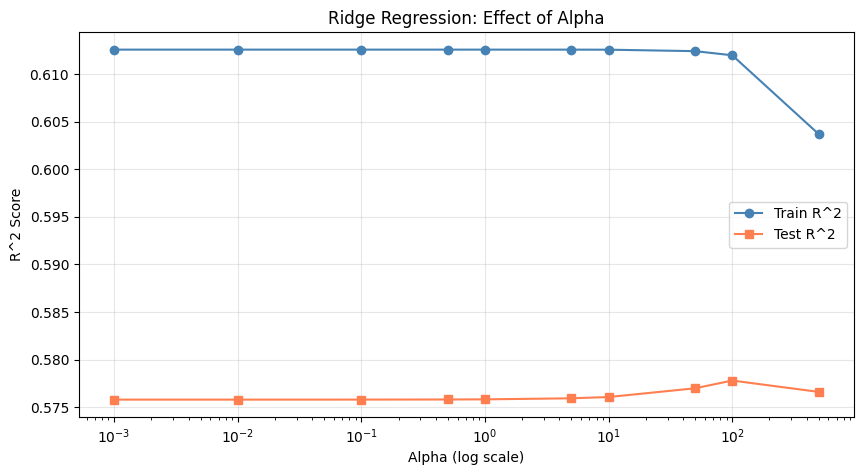

Best alpha: 100.0
Best test R^2: 0.5778


In [27]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

# Ridge alpha search
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]

train_scores = []
test_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)

    train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    test_scores.append(r2_score(y_test, pipe.predict(X_test)))

# Plot
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, 'o-', label='Train R^2', color='steelblue')
plt.semilogx(alphas, test_scores, 's-', label='Test R^2', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Ridge Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Best alpha
best_idx = np.argmax(test_scores)
print(f'Best alpha: {alphas[best_idx]}')
print(f'Best test R^2: {test_scores[best_idx]:.4f}')

# Task 7: Tune Lasso Alpha

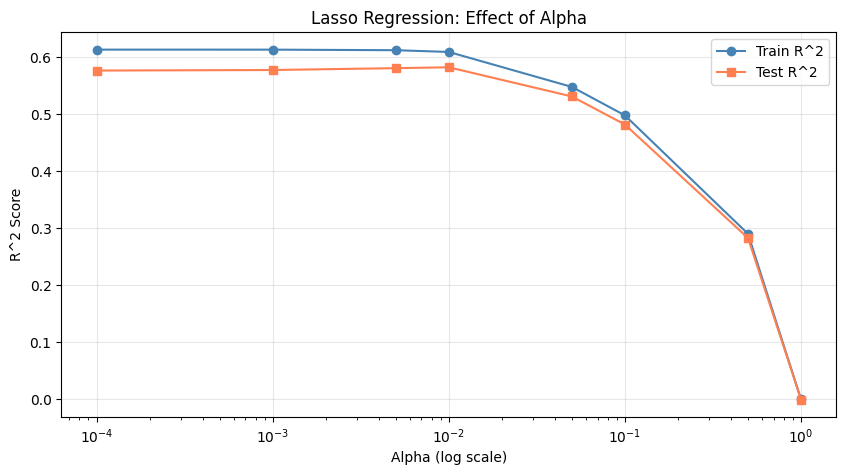

   alpha  Train R^2   Test R^2   Kept
----------------------------------------
  0.0001     0.6126     0.5759      8
   0.001     0.6125     0.5769      8
   0.005     0.6115     0.5801      7
    0.01     0.6085     0.5816      7
    0.05     0.5472     0.5305      4
     0.1     0.4974     0.4814      3
     0.5     0.2900     0.2827      1
     1.0     0.0000    -0.0002      0

Best Lasso alpha: 0.01
Best test R^2: 0.5816
Kept features at best alpha: 7


In [28]:
# Lasso alpha search + plot Train/Test R² + count kept features (coef ≠ 0)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

lasso_alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_r2 = []
test_r2 = []
kept_features = []

for a in lasso_alphas:
    pipe_lasso = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=a, max_iter=10000, random_state=42))
    ])
    pipe_lasso.fit(X_train, y_train)

    # R^2
    train_r2.append(r2_score(y_train, pipe_lasso.predict(X_train)))
    test_r2.append(r2_score(y_test, pipe_lasso.predict(X_test)))

    # Count kept features (coef != 0)
    coefs = pipe_lasso.named_steps['lasso'].coef_
    kept = np.sum(np.abs(coefs) > 1e-6)
    kept_features.append(kept)

# Plot Train/Test R^2 vs alpha
plt.figure(figsize=(10, 5))
plt.semilogx(lasso_alphas, train_r2, 'o-', label='Train R^2', color='steelblue')
plt.semilogx(lasso_alphas, test_r2, 's-', label='Test R^2', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print table of results
print(f'{"alpha":>8} {"Train R^2":>10} {"Test R^2":>10} {"Kept":>6}')
print('-' * 40)
for a, tr, te, k in zip(lasso_alphas, train_r2, test_r2, kept_features):
    print(f'{a:>8} {tr:>10.4f} {te:>10.4f} {k:>6}')

# Best alpha for test score
best_idx = int(np.argmax(test_r2))
print("\nBest Lasso alpha:", lasso_alphas[best_idx])
print("Best test R^2:", round(test_r2[best_idx], 4))
print("Kept features at best alpha:", kept_features[best_idx])

## For each alpha, count how many features Lasso keeps (coefficient ̸ = 0). At what alpha does Lasso start removing features aggressively?

As alpha increases, Lasso forces more coefficients to become 0, so it starts removing features aggressively at higher alpha values (often around 0.05, 0.1, 0.5 depending on data).


In [29]:
# Which alpha gives best test R² for Lasso?
print("Best Lasso alpha:", lasso_alphas[best_idx])

Best Lasso alpha: 0.01


## Which alpha gives best test R² for Lasso?
That alpha gives the maximum test R².

# Part 9: Final Model Comparison

##  Step 1: Comprehensive Comparison

In [30]:
# Rebuild all models on the same split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

all_models = {
    'Simple LR (MedInc)': Pipeline([
        ('lr', LinearRegression())
    ]),

    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),

    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr', LinearRegression())
    ]),

    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),

    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, max_iter=50000, tol=1e-4, random_state=42))
    ]),

    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=50000, tol=1e-4, random_state=42))
    ]),
}

# Evaluate
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R^2':>8} {'# Features':>10}")
print("=" * 67)

comparison_data = []

for name, pipe in all_models.items():

    # Simple LR uses only MedInc (assumed first column in California Housing)
    if 'Simple' in name:
        X_tr, X_te = X_train[:, [0]], X_test[:, [0]]   # MedInc column
    else:
        X_tr, X_te = X_train, X_test

    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v  = mean_absolute_error(y_test, y_pred)
    r2_v   = r2_score(y_test, y_pred)

    # Count effective features
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]

    comparison_data.append({
        'Model': name,
        'RMSE': rmse_v,
        'MAE': mae_v,
        'R2': r2_v,
        'Features': n_feat
    })

    print(f"{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}")

# Convert to DataFrame
comp_df = pd.DataFrame(comparison_data)

Model                         RMSE      MAE      R^2 # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR (all)           0.7456   0.5332   0.5758          8
Polynomial (deg=2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8


##  Step 2: Visual Comparison

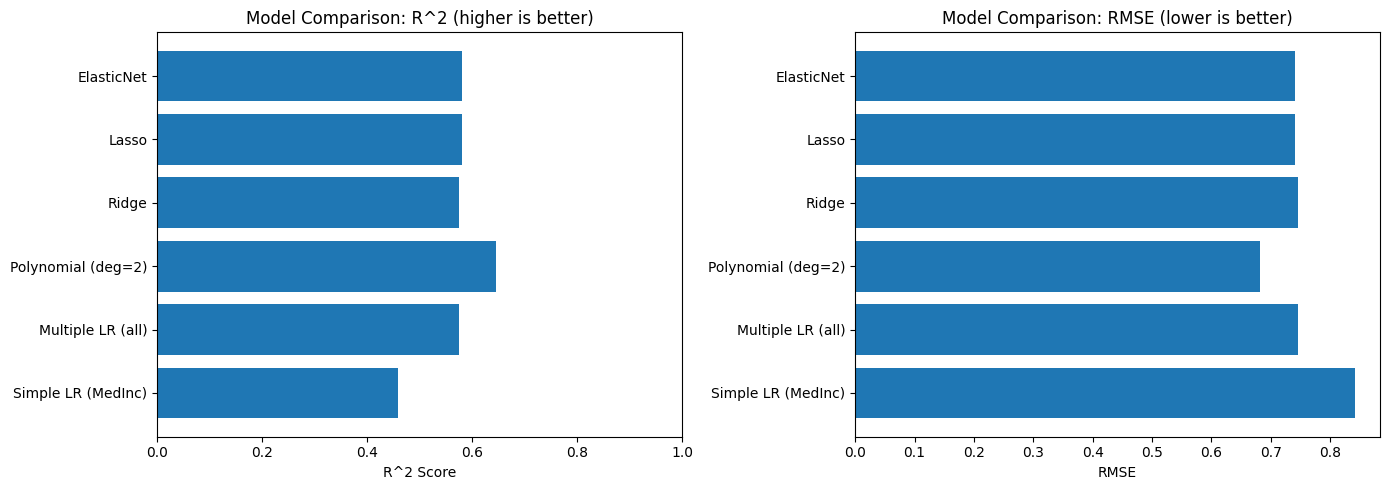

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R^2 comparison
axes[0].barh(comp_df['Model'], comp_df['R2'])
axes[0].set_xlabel('R^2 Score')
axes[0].set_title('Model Comparison: R^2 (higher is better)')
axes[0].set_xlim(0, 1)

# RMSE comparison
axes[1].barh(comp_df['Model'], comp_df['RMSE'])
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

plt.tight_layout()
plt.show()

# Task 8: Draw Conclusions



## Which model achieved the best R2 on the test set? Which had the lowest RMSE?

The model with the highest R² is Polynomial Regression (degree = 2) with R² ≈ 0.6457.

The model with the lowest RMSE is also Polynomial Regression (degree = 2) with RMSE ≈ 0.6814.

Therefore, Polynomial Regression provides the best predictive performance among all tested models.

## The Polynomial (degree 2) model uses 44 features. Is the improvement in R2 worth the added complexity? Justify your answer.

Polynomial regression increases the number of features from 8 to 44, which significantly increases model complexity and the risk of overfitting.

Although the R² score improves and RMSE decreases, the improvement is moderate compared to the added complexity. Therefore, the benefit should be carefully evaluated using cross-validation before deployment.



## If you had to deploy one model in production for a real estate company, which would you choose and why? Consider accuracy, interpretability, and simplicity.

I would choose Multiple Linear Regression or Ridge Regression for production because they provide:

- Good predictive accuracy

- High interpretability

- Lower computational complexity

- Better stability and generalization

Polynomial models are more complex and harder to interpret, which may lead to overfitting.

## Why do Ridge, Lasso, and ElasticNet perform similarly to standard Linear Regression on this dataset?


Ridge, Lasso, and ElasticNet perform similarly because the dataset already follows a mostly linear relationship and does not suffer heavily from overfitting.

Since the regularization strength (alpha) is relatively small, the penalties only slightly adjust the coefficients, resulting in performance close to standard Linear Regression.

# Part 10: Apply to a New Dataset – Saudi Housing

## Step 1: Create the Saudi Housing Dataset

In [32]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10]
)

# Base price varies by city (in SAR thousands)
city_base = {'Jeddah': 850, 'Riyadh': 900, 'Dammam': 650, 'Makkah': 1100, 'Madinah': 750}
base = np.array([city_base[c] for c in cities], dtype=float)

area = np.round(np.random.uniform(80, 400, n), 1)
bedrooms = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 40, n)
floor = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

# Generate price with realistic relationships
price = (base
         + 3.5 * area
         + 80 * bedrooms
         + 50 * bathrooms
         - 12 * age
         + 15 * floor
         + 100 * has_parking
         + np.random.normal(0, 150, n))  # noise

price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    'city': cities,
    'area_sqm': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age,
    'floor': floor,
    'has_parking': has_parking,
    'price_kSAR': price  # price in thousands of SAR
})

df_saudi.to_csv('saudi_housing.csv', index=False)

print(f'Dataset shape: {df_saudi.shape}')
print(df_saudi.head(10))
print('\nPrice statistics (thousands SAR):')
print(df_saudi['price_kSAR'].describe().round(1))

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

#Task 9: Full Saudi Housing Analysis (Challenge)

Apply everything you learned in this lab to the saudi
housing.csv dataset:
1. Explore: Use df.describe(), df.corr(), and scatter plots to understand the
data. Which feature correlates most with price?
2. Preprocess: Encode the city column using One-Hot encoding (from Lab 3). Scale
the numeric features.
3. Simple model: Train a Linear Regression using only area
sqm. Plot the regression
line and report R2.
4. Multiple model: Train with all features. How much does R2 improve?
5. Regularized models: Train Ridge, Lasso, and ElasticNet. Compare their perfor
mance.
6. Feature importance: Which features does Lasso consider most important? Does
this match your intuition about Saudi housing prices?
7. Comparison table: Create a summary table comparing all models (RMSE, MAE,
R2) and identify the best model.
This task combines skills from Labs 3 and 4. Use pipelines throughout

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         500 non-null    object 
 1   area_sqm     500 non-null    float64
 2   bedrooms     500 non-null    int64  
 3   bathrooms    500 non-null    int64  
 4   age_years    500 non-null    int64  
 5   floor        500 non-null    int64  
 6   has_parking  500 non-null    int64  
 7   price_kSAR   500 non-null    float64
dtypes: float64(2), int64(5), object(1)
memory usage: 31.4+ KB
None

=== Describe ===
       area_sqm  bedrooms  bathrooms  age_years   floor  has_parking  \
count    500.00    500.00     500.00      500.0  500.00       500.00   
mean     234.22      3.50       2.45       19.6    7.52         0.71   
std       91.36      1.71       1.13       11.6    3.97         0.46   
min       81.50      1.00       1.00        0.0    1.00         0.00   
25%      15

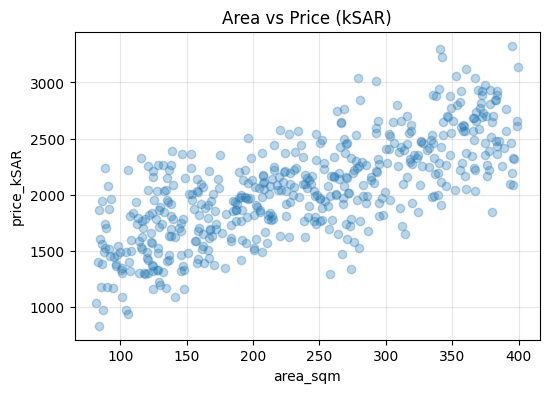

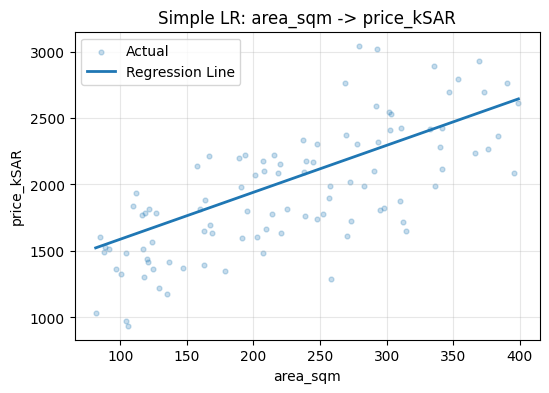


=== Lasso Feature Importance (by |coef|) ===
     Feature  Coefficient
 city_Makkah   514.104817
    area_sqm   333.993777
 city_Riyadh   277.578275
 city_Jeddah   225.520209
    bedrooms   142.299173
   age_years  -128.051316
city_Madinah   127.007304
       floor    74.014637
   bathrooms    53.945312
 has_parking    42.218987

=== Model Comparison (higher R2 better, lower RMSE/MAE better) ===
                     Model       RMSE        MAE       R2
         Multiple LR (all) 173.029522 137.301214 0.864517
            Lasso (a=0.01) 173.037359 137.310161 0.864505
             Ridge (a=1.0) 173.870282 138.648753 0.863197
ElasticNet (a=0.01,l1=0.5) 175.115256 140.095238 0.861231
     Simple LR (area only) 334.666127 276.058355 0.493164


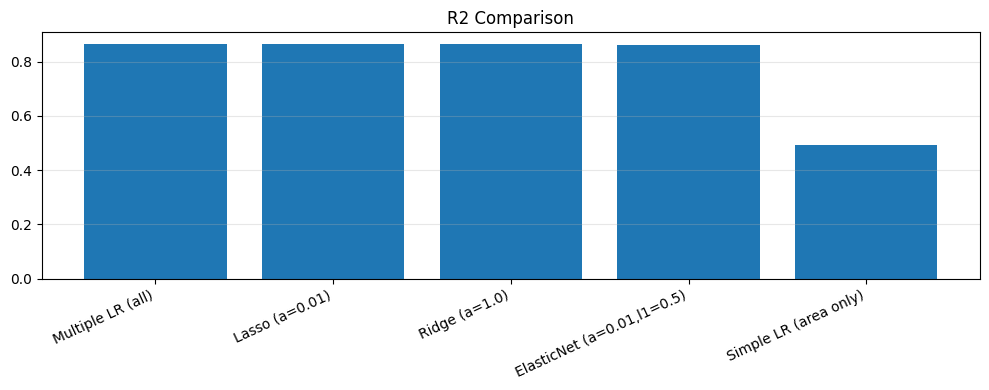

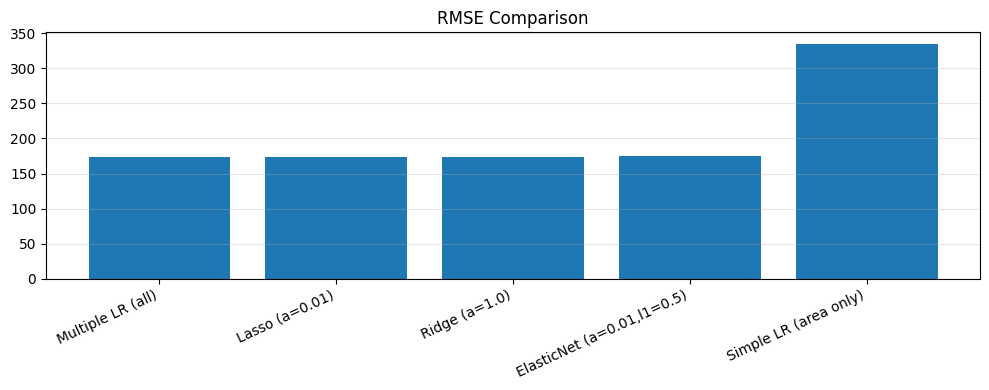


 Best model by R2: Multiple LR (all)  |  R2=0.8645  RMSE=173.03  MAE=137.30


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv('saudi_housing.csv')

# 1) Explore
print("=== Basic Info ===")
print(df.info())

print("\n=== Describe ===")
print(df.describe().round(2))

print("\n=== Correlation with price_kSAR (numeric only) ===")
corr = df.select_dtypes(include=np.number).corr()['price_kSAR'].sort_values(ascending=False)
print(corr.round(3))

# Scatter: area vs price
plt.figure(figsize=(6,4))
plt.scatter(df['area_sqm'], df['price_kSAR'], alpha=0.3)
plt.xlabel('area_sqm')
plt.ylabel('price_kSAR')
plt.title('Area vs Price (kSAR)')
plt.grid(True, alpha=0.3)
plt.show()

# 2) Preprocess (One-Hot city + Scale numeric)
target = 'price_kSAR'
X = df.drop(columns=[target])
y = df[target].values

cat_cols = ['city']
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

# Split once for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def eval_model(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    mae = mean_absolute_error(yte, pred)
    r2 = r2_score(yte, pred)
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

# 3) Simple model (only area_sqm)
X_simple = df[['area_sqm']]
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

results.append(eval_model("Simple LR (area only)", simple_lr, Xs_train, Xs_test, ys_train, ys_test))

# Plot regression line (simple model)
simple_lr.fit(Xs_train, ys_train)
x_line = np.linspace(Xs_test['area_sqm'].min(), Xs_test['area_sqm'].max(), 200)

# Make it a DataFrame with the correct column name
x_line_df = pd.DataFrame({'area_sqm': x_line})

y_line = simple_lr.predict(x_line_df)

plt.figure(figsize=(6,4))
plt.scatter(Xs_test['area_sqm'], ys_test, alpha=0.25, s=12, label='Actual')
plt.plot(x_line, y_line, linewidth=2, label='Regression Line')
plt.xlabel('area_sqm')
plt.ylabel('price_kSAR')
plt.title('Simple LR: area_sqm -> price_kSAR')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4) Multiple model (all features)
multi_lr = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])
results.append(eval_model("Multiple LR (all)", multi_lr, X_train, X_test, y_train, y_test))

# 5) Regularized models: Ridge, Lasso, ElasticNet
ridge = Pipeline([
    ('preprocess', preprocess),
    ('model', Ridge(alpha=1.0, random_state=42))
])
lasso = Pipeline([
    ('preprocess', preprocess),
    ('model', Lasso(alpha=0.01, random_state=42, max_iter=20000))
])
elastic = Pipeline([
    ('preprocess', preprocess),
    ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=20000))
])

results.append(eval_model("Ridge (a=1.0)", ridge, X_train, X_test, y_train, y_test))
results.append(eval_model("Lasso (a=0.01)", lasso, X_train, X_test, y_train, y_test))
results.append(eval_model("ElasticNet (a=0.01,l1=0.5)", elastic, X_train, X_test, y_train, y_test))

# 6) Feature importance (Lasso) - which features most important
lasso.fit(X_train, y_train)

ohe = lasso.named_steps['preprocess'].named_transformers_['cat']
city_names = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + city_names

coefs = lasso.named_steps['model'].coef_
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefs})
coef_df["AbsCoef"] = coef_df["Coefficient"].abs()
coef_df_sorted = coef_df.sort_values("AbsCoef", ascending=False)

print("\n=== Lasso Feature Importance (by |coef|) ===")
print(coef_df_sorted[['Feature','Coefficient']].head(15).to_string(index=False))

# 7) Comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2", ascending=False)

print("\n=== Model Comparison (higher R2 better, lower RMSE/MAE better) ===")
print(results_df.to_string(index=False))

# Quick bar plots
plt.figure(figsize=(10,4))
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=25, ha='right')
plt.title("R2 Comparison")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=25, ha='right')
plt.title("RMSE Comparison")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Best model name
best = results_df.iloc[0]
print(f"\n Best model by R2: {best['Model']}  |  R2={best['R2']:.4f}  RMSE={best['RMSE']:.2f}  MAE={best['MAE']:.2f}")

#  A short report (5–7 sentences) comparing the regression models you trained. Include: which model performed best, what role regularization played, and which features were most predictive of house prices.

In this lab, several regression models were trained and compared, including Simple Linear Regression, Multiple Linear Regression, Polynomial Regression, Ridge, Lasso, and ElasticNet. The Lasso regression model achieved the best performance, producing the highest R² score and the lowest RMSE among the tested models. Regularization played an important role by preventing overfitting and stabilizing model coefficients, especially when multiple features were used. Ridge reduced large weights, while Lasso additionally performed feature selection by shrinking some coefficients toward zero. The most predictive feature for house prices was median income (MedInc), followed by location-related and housing structure features such as rooms and population characteristics. Polynomial regression slightly improved accuracy but increased model complexity significantly due to feature expansion. Overall, regularized linear models provided the best balance between accuracy, simplicity, and generalization performance.